In [1]:
from common_setup import *

In [2]:
import numpy as np
from scipy.optimize import minimize
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import ShuffleSplit
from typing import Tuple, List

def make_polynomial_features(X: np.ndarray, order: int) -> np.ndarray:
    """
    Generate polynomial features up to 'order'.
    If order=1, we get [1, x1, x2, ...].
    If order=2, we get [1, x1, x2, ..., x1^2, x1*x2, ...].
    """
    if order < 1 or order > 2:
        raise ValueError("Only order=1 or order=2 are supported.")
    
    poly = PolynomialFeatures(degree=order, include_bias=True)
    # shape: (n_samples, number_of_poly_features)
    return poly.fit_transform(X)


def sigmoid(s1,s2):
    diff=s1-s2
    ratio_pred=1.0/(1.0+np.exp(-diff))-0.5
    return ratio_pred

def inv_sigmoid(ratio_pred):
    return np.log((ratio_pred + 0.5) / (0.5 - ratio_pred))

def fit_definite_strength_poly(
    X1: np.ndarray,
    X2: np.ndarray,
    y: np.ndarray,
    order: int = 1,
    alpha: List[float] = None,
    w_init: np.ndarray = None
) -> np.ndarray:
    if alpha is None:
        # Default: no regularization if not specified
        alpha = [0.0] * (2 if order == 1 else 3)
    
    if order == 1 and len(alpha) != 2:
        raise ValueError("For order=1, alpha must have length=2.")
    if order == 2 and len(alpha) != 3:
        raise ValueError("For order=2, alpha must have length=3.")
    
    # Transform X1, X2 to polynomial features
    Z1 = make_polynomial_features(X1, order)  # shape: (n_samples, n_poly_features)
    Z2 = make_polynomial_features(X2, order)  # same shape
    n_samples, n_poly_features = Z1.shape
    
    d = X1.shape[1]
    intercept_idx = [0]
    linear_idx = list(range(1, d+1))
    if order == 1:
        quadratic_idx = []
    else:
        quadratic_idx = list(range(d+1, n_poly_features))
    
    alpha0 = alpha[0]  # intercept
    alpha1 = alpha[1]  # linear
    alpha2 = alpha[2] if order == 2 else 0.0  # quadratic (only if order=2)

    # Initial guess
    if w_init is None:
        w_init = np.zeros(n_poly_features)#np.random.randn(n_poly_features)

    def objective(w):
        # Predictions for each sample pair
        s1 = Z1.dot(w)  # shape: (n_samples,)
        s2 = Z2.dot(w)

        ratio_pred = sigmoid(s1,s2)  # shape: (n_samples,)
        # sum of squared errors
        residuals = y - ratio_pred
        sse = np.sum(residuals**2)

        # Regularization
        reg_intercept = alpha0 * np.sum(np.abs(w[intercept_idx]))
        reg_linear = alpha1 * np.sum(np.abs(w[linear_idx]))
        reg_quad = alpha2 * np.sum(np.abs(w[q]) for q in quadratic_idx)
        
        reg = reg_intercept + reg_linear + reg_quad
        return sse + reg

    # Minimize
    result = minimize(objective, w_init, method='BFGS', options={'maxiter': 100000} )
    w_opt = result.x
    return w_opt



def predict_ratio_poly(w: np.ndarray, X1: np.ndarray, X2: np.ndarray, order: int) -> np.ndarray:
    """
    Given fitted parameters w for polynomial of 'order',
    predict ratio = s1 / (s1 + s2).
    """
    Z1 = make_polynomial_features(X1, order)
    Z2 = make_polynomial_features(X2, order)
    s1 = Z1.dot(w)
    s2 = Z2.dot(w)
    return sigmoid(s1,s2)  #



In [3]:
import json
from pathlib import Path




In [4]:
def extract_sc_cc_numeric(loaded_results, rep_num, intensity_index):
    """
    Extracts and converts sc_list and cc_list for a specified intensity and replicate number.

    Parameters
    ----------
    loaded_results : dict
        The nested dictionary containing all results.
    rep_num : int
        The replicate number corresponding to 'community_n' (0 to 9).
    intensity_index : int, optional
        The index of the intensity to select (0-based). Defaults to 2 (third intensity).

    Returns
    -------
    sc_list_numeric : dict
        Sub-community list with integer keys.
    cc_list_numeric : dict
        Coalescence list with tuple integer keys.

    Raises
    ------
    ValueError
        If the loaded_results does not contain enough intensity levels,
        or if the specified community does not exist.
    """
    import sys

    # 1. Retrieve the specified intensity key
    intensity_keys = sorted(loaded_results.keys())
    if len(intensity_keys) <= intensity_index:
        raise ValueError(f"The loaded_results dictionary does not contain an intensity at index {intensity_index}.")

    intensity_key = intensity_keys[intensity_index]
    print(f"Selected Intensity: {intensity_key}")

    # 2. Construct the community key
    community_key = f'community_{rep_num}'
    print(f"Selected Community: {community_key}")

    # 3. Access the community data
    community_data = loaded_results.get(intensity_key, {}).get(community_key, {})
    if not community_data:
        raise ValueError(f"Community '{community_key}' not found under intensity '{intensity_key}'.")

    # 4. Extract sc_list and cc_list
    sc_list = community_data.get('sc_list', {})
    cc_list = community_data.get('cc_list', {})

    # 5. Convert sc_list keys from strings to integers
    sc_list_numeric = {}
    for k, v in sc_list.items():
        try:
            key_num = int(k)
            sc_list_numeric[key_num] = v
        except ValueError:
            print(f"Warning: Invalid sc_list key '{k}'. Skipping.", file=sys.stderr)

    # 6. Convert cc_list keys from 'x_y' strings to (x, y) tuples of integers
    cc_list_numeric = {}
    for k, v in cc_list.items():
        try:
            key_tuple = tuple(int(part) for part in k.split('_'))
            if len(key_tuple) != 2:
                raise ValueError
            cc_list_numeric[key_tuple] = v
        except ValueError:
            print(f"Warning: Invalid cc_list key '{k}'. Expected format 'x_y'. Skipping.", file=sys.stderr)

    return sc_list_numeric, cc_list_numeric


def prepare_X1_X2_y(loaded_results, rep_num, intensity_index,  eps=1e-3):
    """
    Prepares X1_all, X2_all, and y_all by processing sc_list and cc_list.

    Parameters
    ----------
    loaded_results : dict
        The nested dictionary containing all results.
    rep_num : int
        The replicate number corresponding to 'community_n' (0 to 9).
    intensity_index : int, optional
        The index of the intensity to select (0-based). Defaults to 2 (third intensity).
    eps : float, optional
        A small epsilon value to prevent division by zero. Defaults to 1e-3.

    Returns
    -------
    X1_all : list
        List of c1 values.
    X2_all : list
        List of c2 values.
    y_all : list
        List of computed y values.
    """
    # Extract sc_list and cc_list with numeric keys
    sc_list_numeric, cc_list_numeric = extract_sc_cc_numeric(loaded_results, rep_num, intensity_index)

    X1_all, X2_all, y_all = [], [], []

    # Iterate over each coalescence pair
    for (c1_idx, c2_idx), cmix in cc_list_numeric.items():
        c1 = sc_list_numeric.get(c1_idx)
        c2 = sc_list_numeric.get(c2_idx)

        if c1 is None or c2 is None:
            print(f"Warning: Sub-community indices {c1_idx}, {c2_idx} not found. Skipping.", file=sys.stderr)
            continue

        # Apply the metric function
        try:
            u, v, k = metric_VectorDecomposition_onlyPositive(c1, c2, cmix)
        except np.linalg.LinAlgError as e:
            if 'Singular matrix' in str(e):
                print("Singular matrix error occurred.")
                print(f"c1: {c1}")
                print(f"c2: {c2}")
                print(f"cmix: {cmix}")
                # Optional: re-raise the exception or handle it further
                u1=u2=1/sqrt(2)
        # Calculate y
        y = (np.arctan((np.abs(u) + eps) / (np.abs(v) + eps)) / (np.pi / 2)) - 0.5

        # Append to the lists
        X1_all.append(c1)
        X2_all.append(c2)
        y_all.append(y)

    return np.array(X1_all), np.array(X2_all), np.array(y_all)



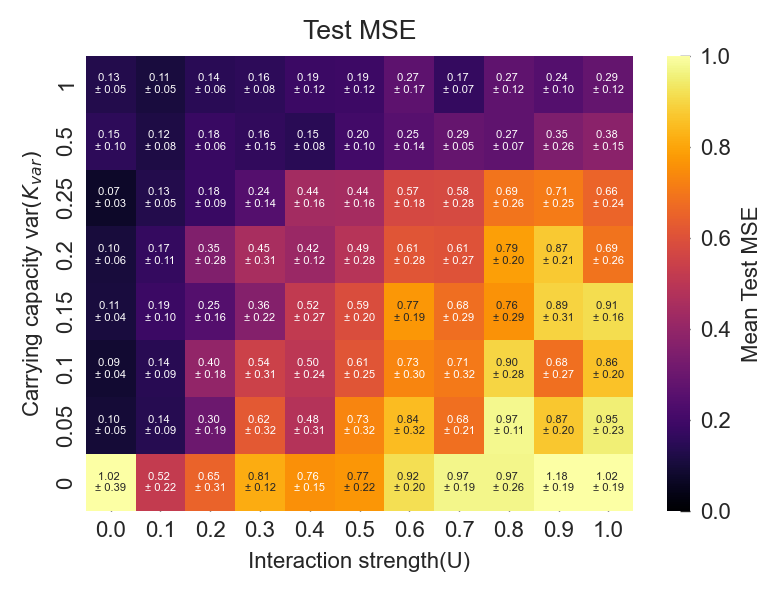

In [44]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define session names and intensity indices
session_names = [
    "Simulation_Data/new_k_gamma_0_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.05_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.1_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.15_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.2_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.25_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.5_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_1_defined_pool_nooverlap_12from48",

]

intensity_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
session_labels = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 1]
intensity_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# 2. Initialize dictionaries to store mean and std MSE values
mean_mse_results = {}
std_mse_results = {}

# 4. Sort sessions based on k_gamma in ascending order
sorted_sessions = session_names[::-1]
session_labels= session_labels[::-1]
# 5. Read JSON files and compute mean and std test MSE
for session_name in sorted_sessions:
    result_file = Path(session_name) / 'prediction_analysis_optimal_alpha_results.json'
    
    if not result_file.exists():
        print(f"Warning: File not found: {result_file}")
        continue
    
    with open(result_file, 'r') as infile:
        try:
            session_results = json.load(infile)
        except json.JSONDecodeError:
            print(f"Error: JSON decoding failed for file: {result_file}")
            continue
    
    # Initialize dictionaries for current session
    mean_mse_results[session_name] = {}
    std_mse_results[session_name] = {}
    
    # Calculate mean and std test MSE for each intensity index
    for idx in intensity_indices:
        if str(idx) in session_results:
            mse_values = session_results[str(idx)]['best_test_mses']
            mean_mse = np.nanmean(mse_values)
            std_mse = np.nanstd(mse_values)
            mean_mse_results[session_name][idx] = mean_mse
            std_mse_results[session_name][idx] = std_mse
        else:
            # Handle missing intensity index
            mean_mse_results[session_name][idx] = np.nan
            std_mse_results[session_name][idx] = np.nan
            print(f"Warning: Intensity index {idx} not found in {result_file}")

# 6. Prepare data for heatmap
heatmap_means = []
heatmap_stds = []

for session_name in sorted_sessions:
    if session_name in mean_mse_results:
        mse_data = mean_mse_results[session_name]
        std_data = std_mse_results[session_name]
        
        # Append mean and std data in the order of intensity_indices
        heatmap_means.append([mse_data.get(idx, np.nan) for idx in intensity_indices])
        heatmap_stds.append([std_data.get(idx, np.nan) for idx in intensity_indices])
        
    else:
        # If session was skipped due to missing file
        continue

heatmap_means = np.array(heatmap_means)
heatmap_stds = np.array(heatmap_stds)

# 7. Create annotation labels combining mean and std
annotations = np.empty_like(heatmap_means, dtype=object)
for i in range(heatmap_means.shape[0]):
    for j in range(heatmap_means.shape[1]):
        mean = heatmap_means[i, j]
        std = heatmap_stds[i, j]
        if np.isnan(mean) or np.isnan(std):
            annotations[i, j] = "N/A"
        else:
            annotations[i, j] = f"{mean:.2f} \n± {std:.2f}"

# 8. Prepare intensity labels by multiplying by 0.1
intensity_labels = [f"{idx * 0.1:.1f}" for idx in intensity_indices]

# 9. Plot heatmap with annotations
plt.figure(figsize=(4, 3))
sns.heatmap(
    heatmap_means, 
    annot=annotations, 
    annot_kws={'size': 4},
    fmt='',  # Custom annotations already formatted
    cmap="inferno", 
    xticklabels=intensity_labels, 
    yticklabels=session_labels,
    cbar_kws={'label': 'Mean Test MSE'},
    vmin=0,   # minimum heatmap color range value
    vmax=1    # maximum heatmap color range value
)
plt.title("Test MSE")
plt.xlabel("Interaction strength(U)")
plt.ylabel("Carrying capacity var$(K_{var})$")

plt.tight_layout()
plt.show()


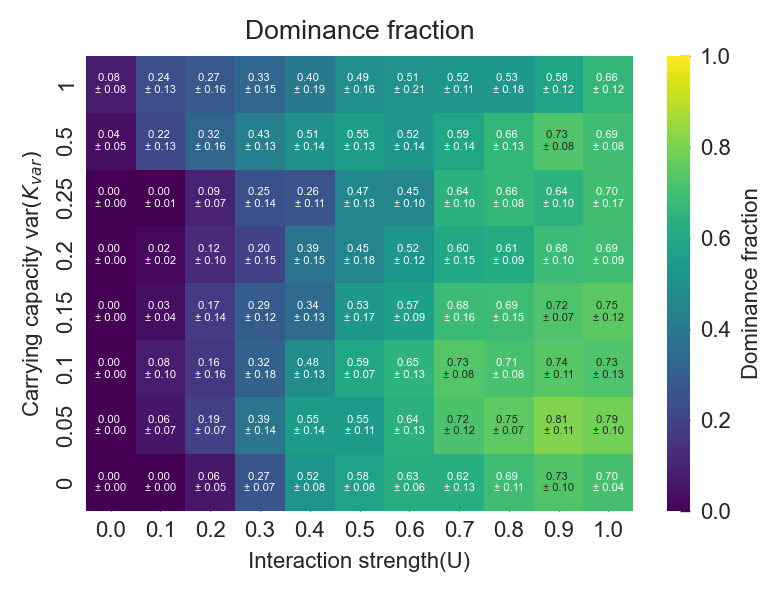

In [45]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Define session names and intensity indices
session_names = [
    "Simulation_Data/new_k_gamma_0_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.05_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.1_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.15_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.2_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.25_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.5_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_1_defined_pool_nooverlap_12from48",

]

intensity_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
session_labels = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 1]
intensity_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
rep_num =8 

# 2. Initialize dictionaries to store mean and std MSE values
mean_mse_results = {}
std_mse_results = {}

# 4. Sort sessions based on k_gamma in ascending order
sorted_sessions = session_names[::-1]
session_labels= session_labels[::-1]
# 5. Read JSON files and compute mean and std test MSE
for session_name in sorted_sessions:
    result_file = Path(session_name) / 'results_dominance_fractions.json'
    
    if not result_file.exists():
        print(f"Warning: File not found: {result_file}")
        continue
    
    with open(result_file, 'r') as infile:
        try:
            session_results = json.load(infile)
        except json.JSONDecodeError:
            print(f"Error: JSON decoding failed for file: {result_file}")
            continue
    
    # Initialize dictionaries for current session
    mean_mse_results[session_name] = {}
    std_mse_results[session_name] = {}
    
    # Calculate mean and std test MSE for each intensity index
    for idx in intensity_indices:
        if str(idx) in session_results:
            mse_values = [np.mean(np.array(session_results[str(idx)][str(i)]['dominance'])==0) for i in range(rep_num)]
            mean_mse =np.nanmean(mse_values)
            std_mse = np.nanstd(mse_values)
            mean_mse_results[session_name][idx] = mean_mse
            std_mse_results[session_name][idx] = std_mse
            
        else:
            # Handle missing intensity index
            mean_mse_results[session_name][idx] = np.nan
            std_mse_results[session_name][idx] = np.nan
            print(f"Warning: Intensity index {idx} not found in {result_file}")

# 6. Prepare data for heatmap
heatmap_means = []
heatmap_stds = []

for session_name in sorted_sessions:
    if session_name in mean_mse_results:
        mse_data = mean_mse_results[session_name]
        std_data = std_mse_results[session_name]
        
        # Append mean and std data in the order of intensity_indices
        heatmap_means.append([mse_data.get(idx, np.nan) for idx in intensity_indices])
        heatmap_stds.append([std_data.get(idx, np.nan) for idx in intensity_indices])
        
    else:
        # If session was skipped due to missing file
        continue

heatmap_means = np.array(heatmap_means)
heatmap_stds = np.array(heatmap_stds)

# 7. Create annotation labels combining mean and std
annotations = np.empty_like(heatmap_means, dtype=object)
for i in range(heatmap_means.shape[0]):
    for j in range(heatmap_means.shape[1]):
        mean = heatmap_means[i, j]
        std = heatmap_stds[i, j]
        if np.isnan(mean) or np.isnan(std):
            annotations[i, j] = "N/A"
        else:
            annotations[i, j] = f"{mean:.2f} \n± {std:.2f}"

# 8. Prepare intensity labels by multiplying by 0.1
intensity_labels = [f"{idx * 0.1:.1f}" for idx in intensity_indices]

# 9. Plot heatmap with annotations
plt.figure(figsize=(4, 3))
sns.heatmap(
    heatmap_means, 
    annot=annotations, 
    annot_kws={'size': 4},
    fmt='',  # Custom annotations already formatted
    cmap="viridis", 
    xticklabels=intensity_labels, 
    yticklabels=session_labels,
    cbar_kws={'label': 'Dominance fraction'},
    vmin=0,   # minimum heatmap color range value
    vmax=1    # maximum heatmap color range value
)
plt.title("Dominance fraction")
plt.xlabel("Interaction strength(U)")
plt.ylabel("Carrying capacity var$(K_{var})$")

plt.tight_layout()
plt.show()


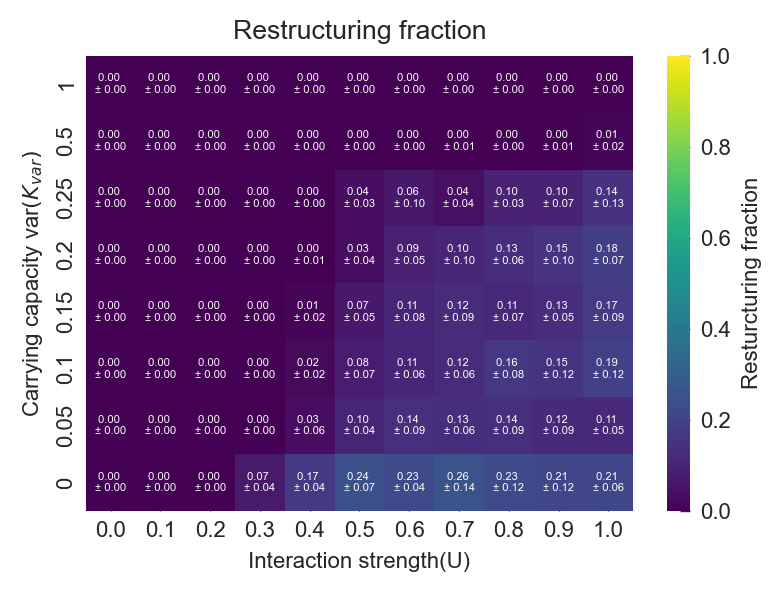

In [46]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Define session names and intensity indices
session_names = [
    "Simulation_Data/new_k_gamma_0_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.05_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.1_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.15_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.2_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.25_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_0.5_defined_pool_nooverlap_12from48",
    "Simulation_Data/new_k_gamma_1_defined_pool_nooverlap_12from48",

]

intensity_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
session_labels = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.5, 1]
intensity_indices = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
rep_num =8 

# 2. Initialize dictionaries to store mean and std MSE values
mean_mse_results = {}
std_mse_results = {}

# 4. Sort sessions based on k_gamma in ascending order
sorted_sessions = session_names[::-1]
session_labels= session_labels[::-1]
# 5. Read JSON files and compute mean and std test MSE
for session_name in sorted_sessions:
    result_file = Path(session_name) / 'results_dominance_fractions.json'
    
    if not result_file.exists():
        print(f"Warning: File not found: {result_file}")
        continue
    
    with open(result_file, 'r') as infile:
        try:
            session_results = json.load(infile)
        except json.JSONDecodeError:
            print(f"Error: JSON decoding failed for file: {result_file}")
            continue
    
    # Initialize dictionaries for current session
    mean_mse_results[session_name] = {}
    std_mse_results[session_name] = {}
    
    # Calculate mean and std test MSE for each intensity index
    for idx in intensity_indices:
        if str(idx) in session_results:
            mse_values = [np.mean(np.array(session_results[str(idx)][str(i)]['dominance'])==2) for i in range(rep_num)]
            mean_mse =np.nanmean(mse_values)
            std_mse = np.nanstd(mse_values)
            mean_mse_results[session_name][idx] = mean_mse
            std_mse_results[session_name][idx] = std_mse
            
        else:
            # Handle missing intensity index
            mean_mse_results[session_name][idx] = np.nan
            std_mse_results[session_name][idx] = np.nan
            print(f"Warning: Intensity index {idx} not found in {result_file}")

# 6. Prepare data for heatmap
heatmap_means = []
heatmap_stds = []

for session_name in sorted_sessions:
    if session_name in mean_mse_results:
        mse_data = mean_mse_results[session_name]
        std_data = std_mse_results[session_name]
        
        # Append mean and std data in the order of intensity_indices
        heatmap_means.append([mse_data.get(idx, np.nan) for idx in intensity_indices])
        heatmap_stds.append([std_data.get(idx, np.nan) for idx in intensity_indices])
        
    else:
        # If session was skipped due to missing file
        continue

heatmap_means = np.array(heatmap_means)
heatmap_stds = np.array(heatmap_stds)

# 7. Create annotation labels combining mean and std
annotations = np.empty_like(heatmap_means, dtype=object)
for i in range(heatmap_means.shape[0]):
    for j in range(heatmap_means.shape[1]):
        mean = heatmap_means[i, j]
        std = heatmap_stds[i, j]
        if np.isnan(mean) or np.isnan(std):
            annotations[i, j] = "N/A"
        else:
            annotations[i, j] = f"{mean:.2f} \n± {std:.2f}"

# 8. Prepare intensity labels by multiplying by 0.1
intensity_labels = [f"{idx * 0.1:.1f}" for idx in intensity_indices]

# 9. Plot heatmap with annotations
plt.figure(figsize=(4, 3))
sns.heatmap(
    heatmap_means, 
    annot=annotations, 
    annot_kws={'size': 4},
    fmt='',  # Custom annotations already formatted
    cmap="viridis", 
    xticklabels=intensity_labels, 
    yticklabels=session_labels,
    cbar_kws={'label': 'Resturcturing fraction'},
    vmin=0,   # minimum heatmap color range value
    vmax=1    # maximum heatmap color range value
)
plt.title("Restructuring fraction")
plt.xlabel("Interaction strength(U)")
plt.ylabel("Carrying capacity var$(K_{var})$")

plt.tight_layout()
plt.show()
